# Laborarbeit - Teil 1

## Datensatz

In diesem Notebook werden Sie selbstständig mit dem Datensatz `passengers-dataset.csv` arbeiten.

Der Datensatz enthält Passagierdaten eines historischen Schiffsunglücks. Das sind die Spalten der Datei:
* PassengerID: Passagier-ID
* Survived: Indikator ob Passagier überlebt hat (1=ja, 0=nein)
* Pclass: Ticketklasse 
* Name: Name des Passagiers
* Sex: Geschlecht des Passagiers
* Age: Alter des Passagiers
* SibSp: Zahl der Geschwister und Ehepartner eines Passagiers an Bord
* Parch: Zahl der Elternteile und Kinder eines Passagiers an Bord
* Ticket: Ticket-ID
* Fare: Ticketpreis
* Cabin: Kabine des Passagiers
* Embarked: Zustiegshafen (C=Cherbourg, Frankreich; Q=Queenstown, Irland; S=Southampton, Großbritannien)

## Aufgabe

**Ihre Aufgabe ist es ein möglichst gutes Modell zu entwickeln, das vorhersagt, ob ein Passagier überlebt.**

## Hinweise

Die Aufgabenstellung ist bewusst offen gehalten. Berücksichtigen Sie bei der Bearbeitung der Aufgabe die folgenden Hinweise:
* Dokumentieren Sie Ihr Vorgehen strukturiert und nachvollziehbar.
* Begründen Sie Ihre Vorgehensweise und Entscheidungen.
* Interpretieren Sie Ergebnisse.
* Erstellen Sie, wo möglich und sinnvoll, Plots.
* **Nutzen Sie nur Methoden, Konzepte und Begründungen, die in der Vorlesung behandelt wurden. Falls dies nicht möglich ist, begründen Sie warum.**
* Identifizieren Sie Schwachstellen/Limitationen Ihrer Arbeit und erläutern Sie diese auf Basis der Vorlesungsinhalte.

Berücksichtigen Sie die folgenden Hinweise für die Abgabe:
* Arbeiten Sie in 2er-Gruppen und geben Sie je Gruppe ein Notebook ab.
* Nennen Sie im abgegebenen Notebook die Gruppenmitglieder.
* **Für die Verwendung von KI berücksichtigen Sie die Hinweise von Herrn Prof. Hänisch.**
* Die erste Abgabe muss am Dienstag, den 17.03., zwischen 15:30 und 16:15 Uhr per Moodle erfolgen.
* Die endgültige Abgabe muss bis Dienstag, den 24.03., um 23:59 Uhr per Moodle erfolgen.
* Gewertet wird die endgültige Abgabe. Wenn Sie zwischen erster und endgültiger Abgabe Änderungen vornehmen, müssen Sie diese begründen.

1. Data Understanding


In [343]:
import pandas as pd

In [344]:
# load data into dataframe
df = pd.read_csv("passengers-dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [346]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"], errors="ignore")
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [347]:
# separate features from target 
y = df["Survived"]
X = df.drop(columns=["Survived"])

In [348]:
# number of examples and features
X.shape

(891, 8)

In [349]:
# missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

Cabin       687
Age         177
Embarked      2
dtype: int64

In [350]:
numerical_data = X.select_dtypes("number")
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     714 non-null    float64
 2   SibSp   891 non-null    int64  
 3   Parch   891 non-null    int64  
 4   Fare    891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [351]:
string_data = X.select_dtypes(object)
string_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sex       891 non-null    object
 1   Cabin     204 non-null    object
 2   Embarked  889 non-null    object
dtypes: object(3)
memory usage: 21.0+ KB


In [352]:
# number of categories per categorical feature
num_categories = string_data.nunique().sort_values(ascending=False)
num_categories

Cabin       147
Embarked      3
Sex           2
dtype: int64

In [353]:
# cabin has 147 categories and 687 null
df_clean = df.drop(columns=["Cabin"], errors="ignore")
df_clean.head

<bound method NDFrame.head of      Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female   NaN      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890         0       3    male  32.0      0      0   7.7500        Q

[891 rows x 8 columns]>

In [354]:
# one-Hot-Encoding categorical features
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,NaN,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


In [355]:
# correlation matrix
corr_matrix = df_encoded.corr()

# correlation with target variable
corr_with_target = corr_matrix["Survived"].sort_values(ascending=False)
top_features = corr_with_target[1:10]
top_features

Fare          0.257307
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.077221
Embarked_S   -0.155660
Pclass       -0.338481
Sex_male     -0.543351
Name: Survived, dtype: float64

In [356]:
# names of top features
top_feature_names = top_features.index

# numerical columns in X
numeric_cols = numerical_data.columns

# check: numerical or categorical
for feature in top_feature_names:
    if feature in numeric_cols:
        print(f"{feature}: numerical")
    else:
        print(f"{feature}: categorial")

Fare: numerical
Parch: numerical
Embarked_Q: categorial
SibSp: numerical
Age: numerical
Embarked_S: categorial
Pclass: numerical
Sex_male: categorial


Data Preparation

In [357]:
selected_features = [
    "Sex_male",
    "Pclass",
    "Fare",
    "Age",
    "Embarked_S",
]

# one-Hot-Encoding categorical features
X = pd.get_dummies(X, drop_first=True)
X

# select
X = X[selected_features]
X.head()

,Sex_male,Pclass,Fare,Age,Embarked_S
0,True,3,7.2500,22.0,True
1,False,1,71.2833,38.0,False
2,False,3,7.9250,26.0,True
3,False,1,53.1000,35.0,True
4,True,3,8.0500,35.0,True


In [358]:
missing_counts = X.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

Age    177
dtype: int64

In [359]:
# Replace missing values in age with median
print(X['Age'].median())

X["Age"] = X["Age"].fillna(X['Age'].median())

X.isna().sum()

28.0


Sex_male      0
Pclass        0
Fare          0
Age           0
Embarked_S    0
dtype: int64

In [360]:
X.shape

(891, 5)

In [361]:
# separation into training and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print(X_train_sub.shape)
print(X_val.shape)
print(X_test.shape)

(712, 5)
(534, 5)
(178, 5)
(179, 5)


In [362]:
# scaling for better comparison of the features and improved stability during training
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# fit only on the training sub-set
X_train_sub = scaler.fit_transform(X_train_sub)

# transform validation and test sets using the training parameters
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# Modeling

In [363]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_results = []

n_estimators_list = [10, 50, 100]
max_depth_list = [3, 5, 10, 20, 30]

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        rf.fit(X_train_sub, y_train_sub)

        train_acc = accuracy_score(y_train_sub, rf.predict(X_train_sub))
        val_acc = accuracy_score(y_val, rf.predict(X_val))

        rf_results.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })

rf_results = pd.DataFrame(rf_results)
rf_results

,n_estimators,max_depth,train_accuracy,val_accuracy
0,10,3,0.831461,0.831461
1,10,5,0.859551,0.820225
2,10,10,0.951311,0.820225
3,10,20,0.970037,0.792135
4,10,30,0.970037,0.792135
5,50,3,0.825843,0.808989
6,50,5,0.861423,0.825843
7,50,10,0.955056,0.837079
8,50,20,0.985019,0.792135
9,50,30,0.985019,0.792135


In [364]:
best_rf_row = rf_results.loc[rf_results["val_accuracy"].idxmax()]
best_rf_row

n_estimators      50.000000
max_depth         10.000000
train_accuracy     0.955056
val_accuracy       0.837079
Name: 7, dtype: float64

In [365]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=int(best_rf_row["max_depth"]),
    random_state=42
)

# now train the model on whole train set, we need to scale them first

X_train_final, X_test_final, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)

best_rf.fit(X_train_final_scaled, y_train)


rf_test_accuracy = accuracy_score(y_test, best_rf.predict(X_test_final_scaled))
print("Test-Accuracy des besten Random Forest:", round(rf_test_accuracy, 4))

Test-Accuracy des besten Random Forest: 0.8212


In [366]:
print("Random Forest Test-Accuracy:", round(rf_test_accuracy, 4))

Random Forest Test-Accuracy: 0.8212


# Evaluation (Schwachstelle & Limitationen)

In [367]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_rf,X,y,cv=cv,scoring="accuracy")

print("Accuracy pro Fold:", scores)

# Berechnen Sie den Mittelwert der Accuracy über alle Folds
print("Mean Accuracy:", scores.mean(), "±", scores.std())

Accuracy pro Fold: [0.84357542 0.83146067 0.83146067 0.8258427  0.84831461]
Mean Accuracy: 0.8361308141359614 ± 0.008406339517628536


# Result:
train_accuracy     0.955056

val_accuracy       0.848315

Test-Accuracy des besten Random Forest: 0.8212

Mean Accuracy: 0.8361308141359614 ± 0.008406339517628536

Das heißt **Overfitting**

# Refine the model

Regularisierung
vereinfachen unseres Model
Use decision tree first and visualize it

In [368]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [369]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, tree_gini.predict(X_train)))
print("Test accuracy :", accuracy_score(y_test, tree_gini.predict(X_test)))

Train accuracy: 0.6292134831460674
Test accuracy : 0.5865921787709497


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


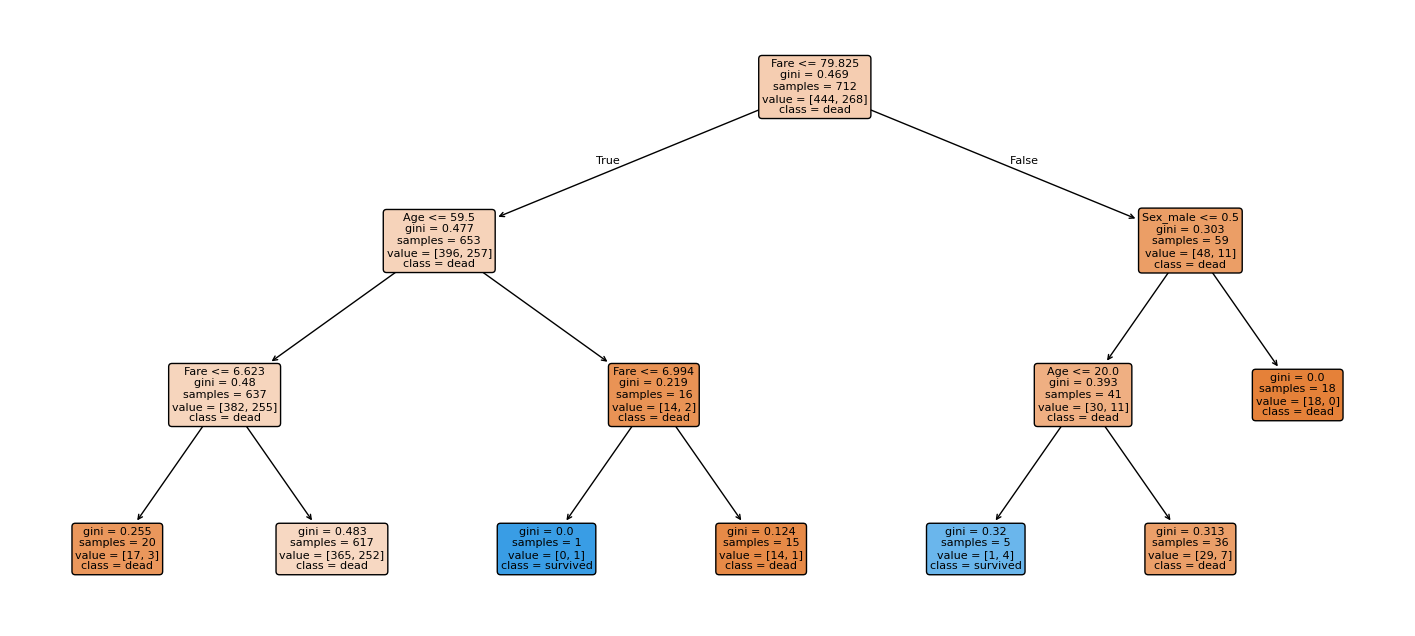

In [370]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=["dead", "survived"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

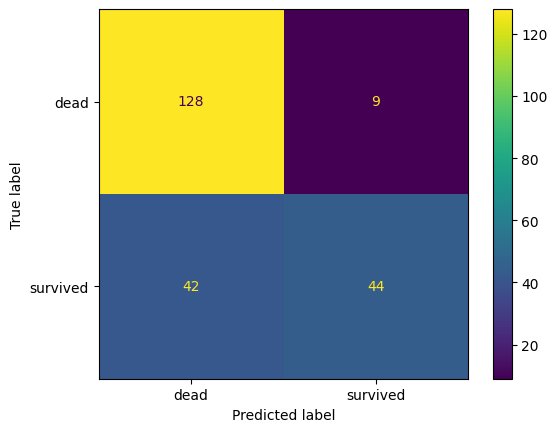

In [388]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_estimator(
    tree_gini,
    X_test,
    y_test,
    display_labels=["dead", "survived"]
)
plt.show()

In [372]:
print(classification_report(y_test, tree_gini.predict(X_test), target_names=["dead", "survived"]))

              precision    recall  f1-score   support

        dead       0.59      1.00      0.74       105
    survived       0.00      0.00      0.00        74

    accuracy                           0.59       179
   macro avg       0.29      0.50      0.37       179
weighted avg       0.34      0.59      0.43       179



/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packa

In [373]:
depths = range(1, 16)

train_scores = []
val_scores = []

for depth in depths:
    tree_depth = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    tree_depth.fit(X_train_sub, y_train_sub)

    train_scores.append(accuracy_score(y_train_sub, tree_depth.predict(X_train_sub)))
    val_scores.append(accuracy_score(y_val, tree_depth.predict(X_val)))

depth_results = pd.DataFrame({
    "max_depth": list(depths),
    "train_accuracy": train_scores,
    "validation_accuracy": val_scores
})

depth_results

,max_depth,train_accuracy,validation_accuracy
0,1,0.786517,0.797753
1,2,0.803371,0.808989
2,3,0.825843,0.848315
3,4,0.842697,0.831461
4,5,0.859551,0.831461
5,6,0.872659,0.825843
6,7,0.893258,0.792135
7,8,0.908240,0.831461
8,9,0.932584,0.797753
9,10,0.947566,0.797753


Beste Validation-Accuracy bei max_depth = 3
Beste Validation-Accuracy: 0.8483


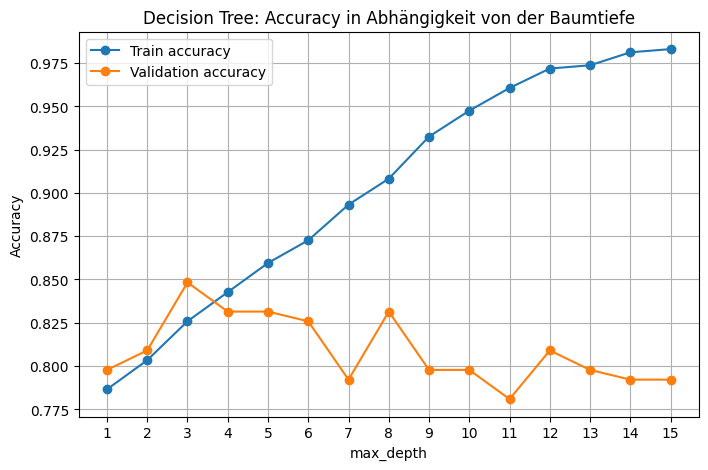

In [374]:
best_depth = depth_results.loc[depth_results["validation_accuracy"].idxmax(), "max_depth"]
best_val_accuracy = depth_results["validation_accuracy"].max()

print("Beste Validation-Accuracy bei max_depth =", best_depth)
print("Beste Validation-Accuracy:", round(best_val_accuracy, 4))

plt.figure(figsize=(8, 5))
plt.plot(depth_results["max_depth"], depth_results["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(depth_results["max_depth"], depth_results["validation_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy in Abhängigkeit von der Baumtiefe")
plt.xticks(list(depths))
plt.grid(True)
plt.legend()
plt.show()


In [375]:
tree_tuned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=best_depth,
    random_state=42
)
tree_tuned.fit(X_train, y_train)

y_pred_tuned = tree_tuned.predict(X_test)
dt_test_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Test-Accuracy des mit dem Validation Set getunten Modells:", round(accuracy_score(y_test, y_pred_tuned), 4))

Test-Accuracy des mit dem Validation Set getunten Modells: 0.5866


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Logistische Regression

In [376]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np

In [377]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

In [378]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

val_accuracies = []

for C in C_values:
    model_l2 = Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(penalty="l2", C=C))
    ])

    model_l2.fit(X_train, y_train)

    val_acc = accuracy_score(y_val, model_l2.predict(X_val))
    val_accuracies.append(val_acc)

    print(f"C={C} | validation accuracy = {val_acc}")

best_idx = np.argmax(val_accuracies)
best_C = C_values[best_idx]

print("Best C based on validation:", best_C)
print("Best validation accuracy:", val_accuracies[best_idx])


C=0.001 | validation accuracy = 0.7921348314606742


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C=0.01 | validation accuracy = 0.797752808988764
C=0.1 | validation accuracy = 0.8314606741573034
C=1.0 | validation accuracy = 0.8258426966292135
C=10.0 | validation accuracy = 0.8370786516853933
Best C based on validation: 10.0
Best validation accuracy: 0.8370786516853933


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

In [379]:
# use 10 as C
pipe_log = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", C=1.0))
])

pipe_log.fit(X_train_sub, y_train_sub)
test_acc = accuracy_score(y_test, pipe_log.predict(X_test))

print("Final model performance:")
print("Test accuracy:", test_acc)


Final model performance:
Test accuracy: 0.7821229050279329


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Support vector

In [ ]:
from sklearn.svm import SVC

In [381]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipe_svc.fit(X_train, y_train)
svc_acc = accuracy_score(y_test, pipe_log.predict(X_test))

print("Final model performance:")
print("Test accuracy:", svc_acc)


Final model performance:
Test accuracy: 0.7821229050279329


In [382]:
from sklearn.neural_network import MLPClassifier
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(30, 15),   
        activation="relu",
        solver="adam",
        alpha=1e-4,                   
        random_state=42
    ))
])

pipe_mlp.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, pipe_mlp.predict(X_train)))
print("Test accuracy :", accuracy_score(y_test, pipe_mlp.predict(X_test)))

Train accuracy: 0.8384831460674157
Test accuracy : 0.7877094972067039


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [392]:
pipe_log = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", max_iter=1000))
])


pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42, max_iter=1000))
])

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=10, random_state=42, max_iter=1000))
])

pipe_tree = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42, max_depth=4))
])

# dictionary for all the pipelines
pipelines = {
    "log reg": pipe_log,
    "mlp": pipe_mlp,
    "svc": pipe_svc,
    "tree": pipe_tree,
}

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25, stratify=y)

# cross validation and compare the scores of those pipelines
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{name}: {scores.mean()}, ±, {scores.std()}")


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

log reg: 0.8143642688811582, ±, 0.016013667664095545
mlp: 0.8024127482886321, ±, 0.029236699880502735
svc: 0.8143867130512848, ±, 0.015033866785849071
tree: 0.8203456402199528, ±, 0.02014004442316784


In [ ]:
# svc and tree has better avergae accuracy

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, tree_gini.predict(X_train)))
print("Test accuracy :", accuracy_score(y_test, tree_gini.predict(X_test)))


print(classification_report(y_test, tree_gini.predict(X_test), target_names=["dead", "survived"]))

Train accuracy: 0.8308383233532934
Test accuracy : 0.7713004484304933
              precision    recall  f1-score   support

        dead       0.75      0.93      0.83       137
    survived       0.83      0.51      0.63        86

    accuracy                           0.77       223
   macro avg       0.79      0.72      0.73       223
weighted avg       0.78      0.77      0.76       223



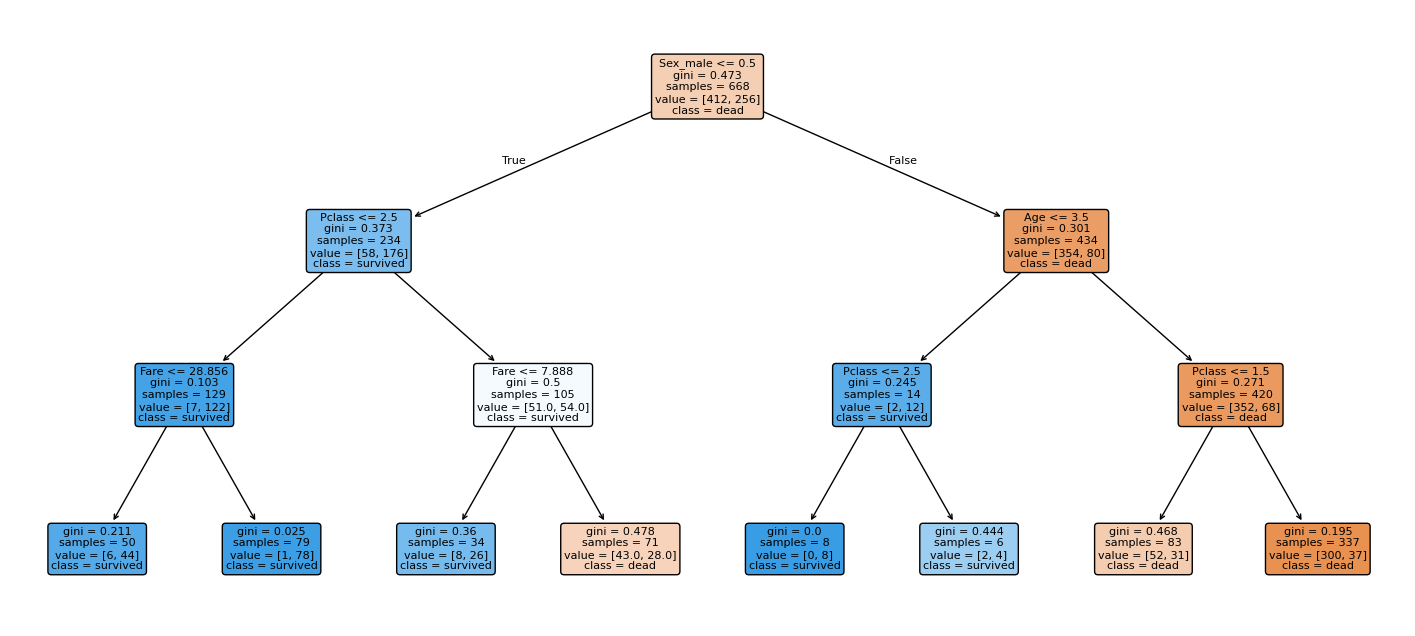

In [386]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=["dead", "survived"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

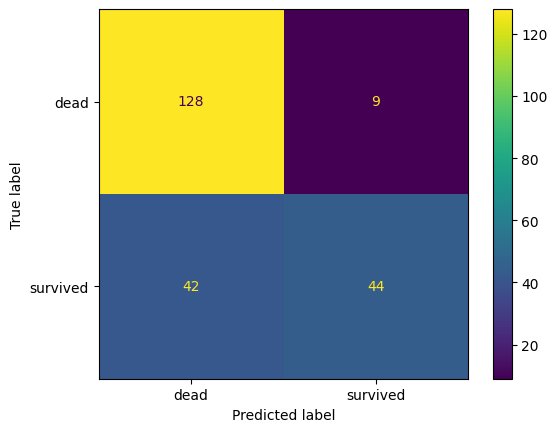

In [387]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_estimator(
    tree_gini,
    X_test,
    y_test,
    display_labels=["dead", "survived"]
)
plt.show()

In [389]:
print(classification_report(y_test, tree_gini.predict(X_test), target_names=["dead", "survived"]))

              precision    recall  f1-score   support

        dead       0.75      0.93      0.83       137
    survived       0.83      0.51      0.63        86

    accuracy                           0.77       223
   macro avg       0.79      0.72      0.73       223
weighted avg       0.78      0.77      0.76       223



In [ ]:
depths = range(1, 16)

train_scores = []
val_scores = []

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

# scalierung

scaler = StandardScaler()
X_train_sub = scaler.fit_transform(X_train_sub)

for depth in depths:
    tree_depth = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    tree_depth.fit(X_train_sub, y_train_sub)

    train_scores.append(accuracy_score(y_train_sub, tree_depth.predict(X_train_sub)))
    val_scores.append(accuracy_score(y_val, tree_depth.predict(X_val)))

depth_results = pd.DataFrame({
    "max_depth": list(depths),
    "train_accuracy": train_scores,
    "validation_accuracy": val_scores
})

depth_results

/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature name

,max_depth,train_accuracy,validation_accuracy
0,1,0.796407,0.616766
1,2,0.808383,0.616766
2,3,0.832335,0.616766
3,4,0.846307,0.616766
4,5,0.852295,0.413174
5,6,0.874251,0.413174
6,7,0.892216,0.413174
7,8,0.918164,0.413174
8,9,0.932136,0.413174
9,10,0.942116,0.413174
